# Análisis de Víctimas en Incidentes Viales — Medellín (2014-2021)
### Proyecto — Análisis de datos con Python

**Integrantes:** _marlon sampayo_
**Dataset:** Víctimas en incidentes viales — Secretaría de Movilidad, Alcaldía de Medellín (portal MEData)
**Fuente:** medata.app.medellin.gov.co


## 1. Importar librerías

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline


## 2. Leer y explorar el dataset

El archivo viene de MEData, el portal de datos abiertos de la Alcaldía de Medellín.
Cada fila representa una **víctima** de un incidente vial (herido o muerto) entre 2014 y 2021.


In [21]:
df = pd.read_csv("Mede_Victimas_inci.csv", low_memory=False)
print("Filas y columnas:", df.shape)
df.head()


Filas y columnas: (1048317, 19)


,Gravedad_victima,Fecha_incidente,Hora_incidente,Clase_incidente,Direccion_incidente,Sexo,Edad,Condicion,Mes,Dia,Num_dia,Hora,Grupo_edad,Año,Radicado,Latitud,Longitud,Comuna,Barrio
0,Heridos,1/01/2014,00:15:00,Otro,CR 49 CL 72,M,17,Motociclista,Ene,Mié,1.0,0,10 - 19,2014.0,1423940,"6,26691466","-75,5590994",04 - Aranjuez,Manrique Central No. 1
1,Heridos,1/01/2014,00:30:00,Atropello,CR 46 CL 98,M,20,Motociclista,Ene,Mié,1.0,0,20 - 29,2014.0,1423921,"6,289353458","-75,55329197",01 - Popular,Moscú No. 2
2,Heridos,1/01/2014,00:30:00,Atropello,CR 46 CL 98,F,18,Peatón,Ene,Mié,1.0,0,10 - 19,2014.0,1423921,"6,289353458","-75,55329197",01 - Popular,Moscú No. 2
3,Heridos,1/01/2014,00:37:00,Atropello,CL 32 CR 84,M,19,Motociclista,Ene,Mié,1.0,0,10 - 19,2014.0,1423849,"6,234327372","-75,60761079",16 - Belén,Las Mercedes
4,Heridos,1/01/2014,00:37:00,Atropello,CL 32 CR 84,M,39,Peatón,Ene,Mié,1.0,0,30 - 39,2014.0,1423849,"6,234327372","-75,60761079",16 - Belén,Las Mercedes


In [22]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048317 entries, 0 to 1048316
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Gravedad_victima     235843 non-null  object 
 1   Fecha_incidente      235843 non-null  object 
 2   Hora_incidente       235843 non-null  object 
 3   Clase_incidente      235843 non-null  object 
 4   Direccion_incidente  235831 non-null  object 
 5   Sexo                 235843 non-null  object 
 6   Edad                 235335 non-null  object 
 7   Condicion            235843 non-null  object 
 8   Mes                  235843 non-null  object 
 9   Dia                  235843 non-null  object 
 10  Num_dia              235843 non-null  float64
 11  Hora                 235843 non-null  object 
 12  Grupo_edad           235843 non-null  object 
 13  Año                  235843 non-null  float64
 14  Radicado             235838 non-null  object 
 15  Latitud        

## 3. Limpieza de datos

Al explorar el archivo encontramos varios problemas típicos de un export gubernamental:

- Cientos de miles de **filas completamente vacías** al final del archivo (artefacto del export,
  el CSV quedó guardado hasta el límite de filas de Excel).
- **Latitud/Longitud** guardadas como texto con coma decimal (`"6,266..."`) en vez de punto.
- **Sexo** y **Condicion** con inconsistencias de mayúsculas (`Sin Inf` vs `Sin inf`,
  `Acompañante de Motocicleta` vs `Acompañante de motocicleta`).
- El texto **"Sin Inf" / "Sin inf" funciona como un NaN disfrazado** en varias columnas
  (`Sexo`, `Edad`, `Hora`, `Hora_incidente`, `Grupo_edad`, `Comuna`, `Barrio`,
  `Direccion_incidente`, además de `Latitud`/`Longitud`), pero no está marcado como dato
  faltante real — queda como si fuera una categoría más. Lo normalizamos a `NaN` explícito
  en todas las columnas, no solo en las numéricas.
- **Edad** como texto, con el valor `"Sin Inf"` mezclado con números.
- **Fecha_incidente** como texto en vez de fecha.
- Un puñado de filas duplicadas.


In [23]:
# 1) Eliminar filas completamente vacías
print("Filas antes:", df.shape[0])
df = df.dropna(subset=["Gravedad_victima"]).copy()
print("Filas con datos reales:", df.shape[0])


Filas antes: 1048317
Filas con datos reales: 235843


In [24]:
# 2) Eliminar duplicados exactos
print("Duplicados encontrados:", df.duplicated().sum())
df = df.drop_duplicates()
print("Filas después de quitar duplicados:", df.shape[0])


Duplicados encontrados: 197
Filas después de quitar duplicados: 235646


In [25]:
# 3) Normalizar texto: Sexo y Condicion tienen inconsistencias de mayúsculas/minúsculas
df["Sexo"] = df["Sexo"].replace({"Sin inf": "Sin Inf"})
df["Condicion"] = df["Condicion"].replace({"Acompañante de motocicleta": "Acompañante de Motocicleta"})

df["Latitud"] = pd.to_numeric(df["Latitud"].astype(str).str.replace(",", ".", regex=False), errors="coerce")
df["Longitud"] = pd.to_numeric(df["Longitud"].astype(str).str.replace(",", ".", regex=False), errors="coerce")


In [26]:
# 4) Edad y Hora a numérico (Sin Inf -> NaN), fecha a datetime
df["Edad"] = pd.to_numeric(df["Edad"], errors="coerce")
df["Hora_num"] = pd.to_numeric(df["Hora"], errors="coerce")
df["Fecha_incidente"] = pd.to_datetime(df["Fecha_incidente"], format="%d/%m/%Y", errors="coerce")
df["Año"] = df["Año"].astype(int)

# 5) "Sin Inf" / "Sin inf" como NaN real en el resto de columnas categóricas
# (en Edad, Hora y las coordenadas ya quedó resuelto arriba al convertir a numérico)
cols_texto_con_sin_inf = [
    "Sexo", "Grupo_edad", "Comuna", "Barrio",
    "Direccion_incidente", "Hora_incidente",
]
for col in cols_texto_con_sin_inf:
    df[col] = df[col].replace({"Sin Inf": np.nan, "Sin inf": np.nan})

print("Nulos tras marcar 'Sin Inf' como NaN:")
print(df[cols_texto_con_sin_inf + ["Edad", "Hora_num", "Latitud", "Longitud"]].isna().sum())

df[["Edad", "Fecha_incidente", "Latitud", "Longitud"]].describe(include="all")


Nulos tras marcar 'Sin Inf' como NaN:
Sexo                    2475
Grupo_edad              2524
Comuna                 21712
Barrio                 21868
Direccion_incidente       12
Hora_incidente             5
Edad                    2405
Hora_num                   7
Latitud                20832
Longitud               20832
dtype: int64


,Edad,Fecha_incidente,Latitud,Longitud
count,233241.000000,235646,214814.000000,214814.000000
mean,32.399248,2017-09-25 21:38:49.979715584,5.452567,-74.774848
min,0.000000,2014-01-01 00:00:00,-75.692411,-75.703902
25%,22.000000,2015-11-03 00:00:00,6.234505,-75.587702
50%,29.000000,2017-08-18 00:00:00,6.254136,-75.574403
75%,40.000000,2019-08-16 00:00:00,6.276040,-75.562324
max,137.000000,2021-09-30 00:00:00,6.368375,6.345891
std,14.844523,NaN,8.058902,8.063733


### 3.1 Exportar el dataset depurado

Guardamos el resultado de la limpieza en un CSV aparte. Este es el archivo que debe usarse
como punto de partida en los notebooks de modelos de predicción de cada integrante del
equipo (no se debe repetir la depuración allí).


In [27]:
df.to_csv("victimas_depuradas.csv", index=False, encoding="utf-8-sig")
print("Dataset depurado exportado a victimas_depuradas.csv")
print("Filas:", df.shape[0], " Columnas:", df.shape[1])


Dataset depurado exportado a victimas_depuradas.csv
Filas: 235646  Columnas: 20


## 4. Análisis: patrones y tendencias

Exploramos cómo se distribuyen las víctimas por año, comuna, tipo de actor vial, hora del día
y día de la semana.


In [28]:
# Víctimas por año y gravedad
por_anio = df.groupby(["Año", "Gravedad_victima"]).size().unstack(fill_value=0)
por_anio


Gravedad_victima,Heridos,Muertos
Año,,
2014,31118,290
2015,32345,274
2016,33518,271
2017,31400,258
2018,28843,239
2019,31554,247
2020,23419,196
2021,21500,174


In [29]:
# Top 10 comunas con más víctimas
top_comunas = df["Comuna"].value_counts().head(10)
top_comunas


,count
Comuna,
10 - La Candelaria,36953
05 - Castilla,22865
11 - Laureles Estadio,19916
07 - Robledo,16682
04 - Aranjuez,14524
15 - Guayabal,14374
16 - Belén,13634
14 - El Poblado,12238
09 - Buenos Aires,9422


In [30]:
# Gravedad por tipo de actor vial (Condicion)
tabla = pd.crosstab(df["Condicion"], df["Gravedad_victima"])
tabla["Total"] = tabla.sum(axis=1)
tabla.sort_values("Total", ascending=False)


Gravedad_victima,Heridos,Muertos,Total
Condicion,,,
Motociclista,141368,725,142093
Acompañante de Motocicleta,35984,158,36142
Peatón,31486,890,32376
Pasajero,13408,41,13449
Conductor,6149,39,6188
Ciclista,5302,96,5398


## 5. Visualización de resultados

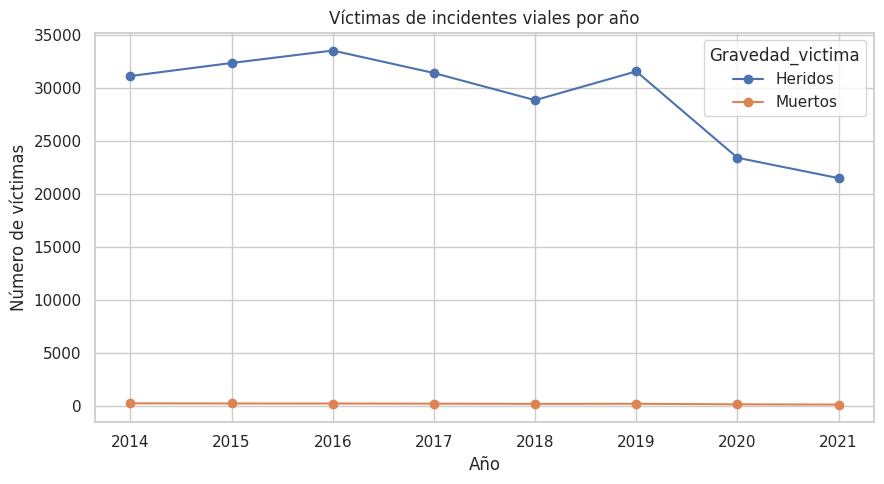

In [31]:
fig, ax = plt.subplots(figsize=(9, 5))
por_anio.plot(kind="line", marker="o", ax=ax)
ax.set_title("Víctimas de incidentes viales por año")
ax.set_xlabel("Año")
ax.set_ylabel("Número de víctimas")
plt.tight_layout()
plt.show()


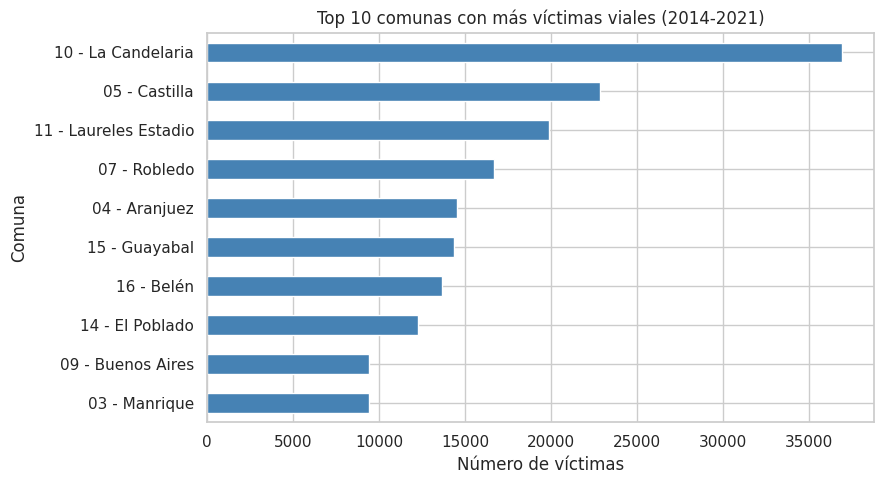

In [32]:
fig, ax = plt.subplots(figsize=(9, 5))
top_comunas.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 10 comunas con más víctimas viales (2014-2021)")
ax.set_xlabel("Número de víctimas")
plt.tight_layout()
plt.show()


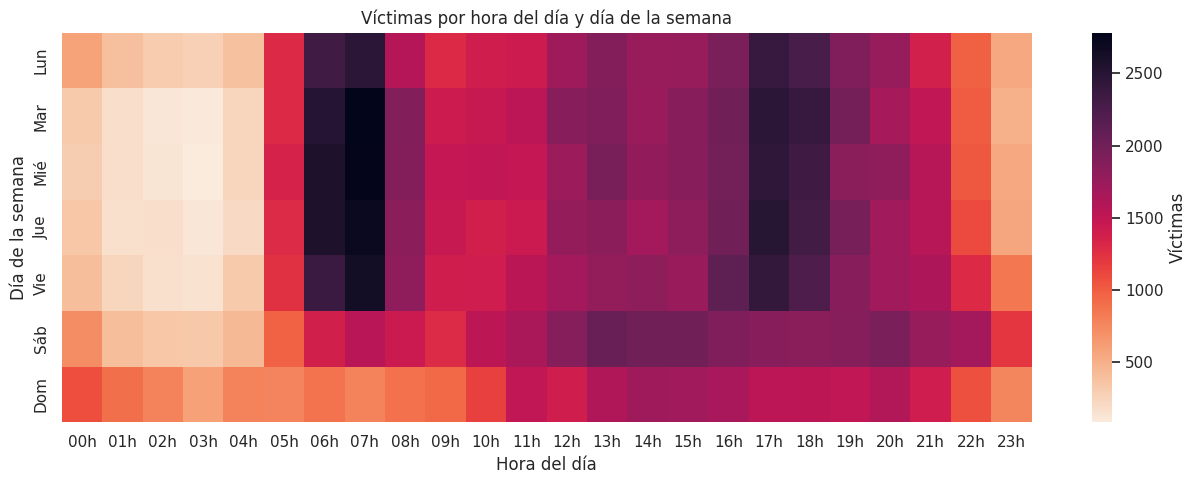

In [33]:
orden_dias = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
tabla_hd = df.dropna(subset=["Hora_num"]).pivot_table(
    index="Dia", columns="Hora_num", values="Radicado", aggfunc="count", fill_value=0
)
tabla_hd = tabla_hd.reindex(orden_dias)
tabla_hd.columns = [f"{int(h):02d}h" for h in tabla_hd.columns]

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(tabla_hd, cmap="rocket_r", ax=ax, cbar_kws={"label": "Víctimas"})
ax.set_title("Víctimas por hora del día y día de la semana")
ax.set_xlabel("Hora del día")
ax.set_ylabel("Día de la semana")
plt.tight_layout()
plt.show()


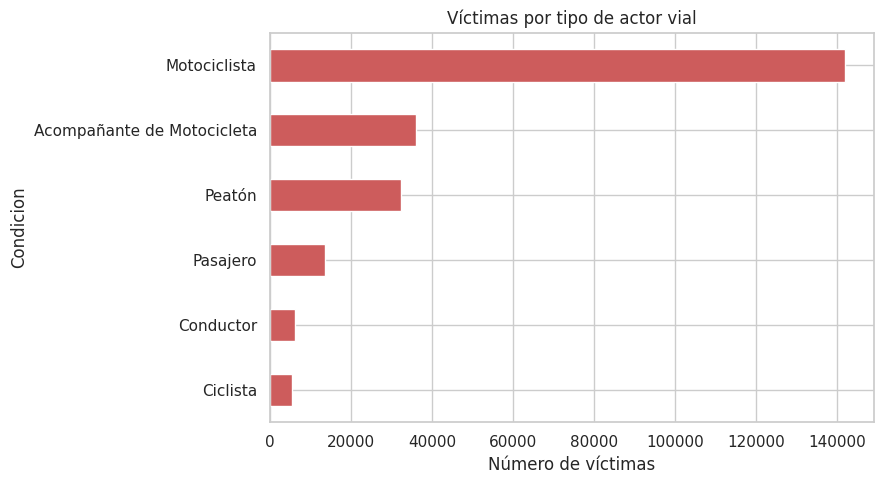

In [34]:
condicion_counts = df["Condicion"].value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
condicion_counts.sort_values().plot(kind="barh", ax=ax, color="indianred")
ax.set_title("Víctimas por tipo de actor vial")
ax.set_xlabel("Número de víctimas")
plt.tight_layout()
plt.show()


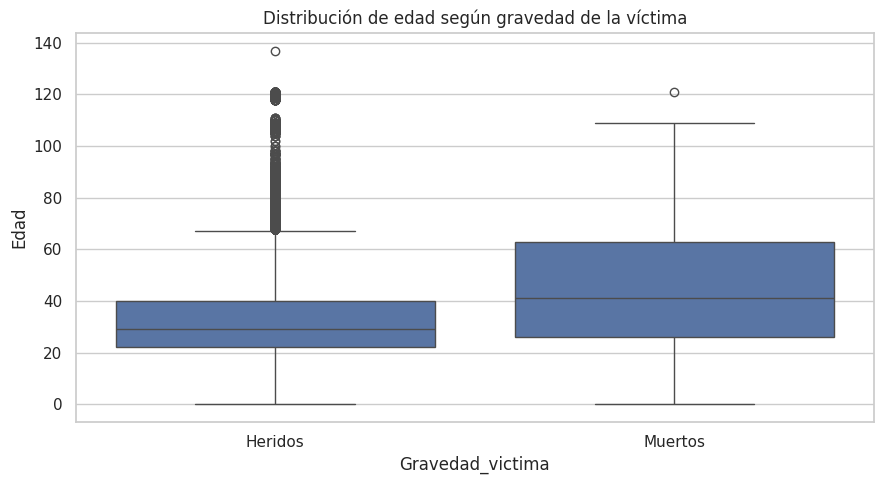

In [35]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="Gravedad_victima", y="Edad", ax=ax)
ax.set_title("Distribución de edad según gravedad de la víctima")
plt.tight_layout()
plt.show()


## Hallazgos:

Hallazgo 1 (Ubicación de mayor siniestralidad): La comuna con mayor número de víctimas registradas es La Candelaria (Comuna 10 - Centro). Esto no es casualidad: al ser el núcleo administrativo, comercial y de transbordo de Medellín, concentra el flujo vehicular y peatonal más denso de la ciudad a lo largo de todo el día.

Hallazgo 2 (Vulnerabilidad por actor vial): Los motociclistas (tanto conductores como acompañantes) representan la inmensa mayoría de las víctimas en los incidentes registrados. Están alarmantemente por encima de los peatones, ciclistas y ocupantes de vehículos de cuatro ruedas, lo que refleja un problema crítico de imprudencia, falta de pericia o desprotección estructural en este grupo.

Hallazgo 3 (Impacto de las restricciones de movilidad): Se evidencia un descenso drástico en las cifras de víctimas entre 2020 y 2021. Este comportamiento está directamente correlacionado con los aislamientos preventivos y las restricciones de circulación decretadas durante la pandemia del COVID-19.

Hallazgo 4 (Franjas horarias y patrones temporales): Al cruzar las variables de hora y día de la semana mediante el mapa de calor, se identifican picos claros de siniestralidad en las horas de mayor flujo (horas pico de la mañana y al final de la tarde), así como un incremento de casos severos durante los fines de semana en horarios nocturnos y madrugadas.

Conclusión general:

Los datos demuestran que la accidentalidad vial en Medellín no es aleatoria, sino un fenómeno focalizado principalmente en los motociclistas y concentrado en corredores del centro de la ciudad. Se sugiere a la Secretaría de Movilidad priorizar intervenciones operativas y pedagógicas dirigidas al gremio motociclista, así como reforzar el control de velocidad y la presencia de agentes en La Candelaria durante las horas pico y madrugadas de fin de semana. Con estas medidas focalizadas se lograría un impacto directo y significativo en la reducción de lesionados y fallecidos en las vías.